<a href="https://colab.research.google.com/github/CharlesRajaR/ml_notebooks/blob/main/machine_learning_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction
## Author: Charles Raja R

# **Data cleaning**


import libraries and load dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
df = titanic
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,True
887,False
888,False
889,False


In [ ]:
df.duplicated().sum()

np.int64(107)

In [ ]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['sex', 'embarked', 'who', 'embark_town', 'alive']
Numerical columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'adult_male', 'deck', 'alone']


In [ ]:
df[cat_col].nunique()

,0
sex,2
embarked,3
who,3
embark_town,3
alive,2


In [ ]:
df.shape

(891, 15)

In [ ]:
df.shape[0]

889

In [ ]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

,0
survived,0.00
pclass,0.00
sex,0.00
age,19.87
sibsp,0.00
parch,0.00
fare,0.00
embarked,0.22
class,0.00
who,0.00


In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())

In [ ]:
df.dropna(subset=['embarked'], inplace=True)

In [ ]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

,0
survived,0.00
pclass,0.00
sex,0.00
age,0.00
sibsp,0.00
parch,0.00
fare,0.00
embarked,0.00
class,0.00
who,0.00


In [ ]:
df['deck'].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [ ]:
df['deck'].value_counts()

,count
deck,
C,59
B,45
D,33
E,32
A,15
F,13
G,4


In [ ]:
df['deck'].isna().sum()

np.int64(688)

In [ ]:
df.drop(columns=['deck'], inplace=True)

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        889 non-null    object  
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [ ]:
df.embarked.unique()

array(['S', 'C', 'Q'], dtype=object)

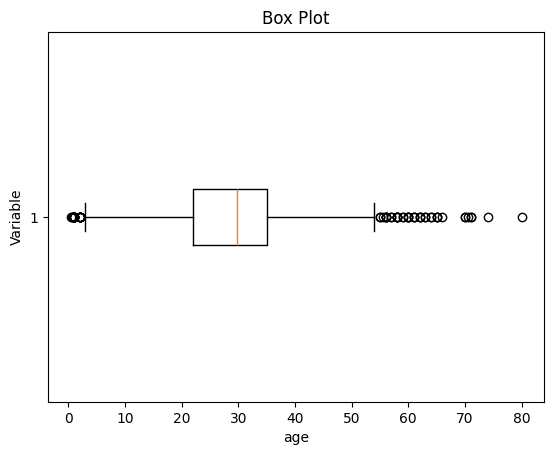

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('age')
plt.title('Box Plot')
plt.show()

In [ ]:
df.age.min()

0.42

In [ ]:
df.age.max()

80.0

In [ ]:
mean = df['age'].mean()
std = df['age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

Lower Bound : 3.7167137521695857
Upper Bound : 55.59017898917891


In [ ]:
mean = df['age'].mean()
std = df['age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

In [ ]:
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     821 non-null    int64   
 1   pclass       821 non-null    int64   
 2   sex          821 non-null    object  
 3   age          821 non-null    float64 
 4   sibsp        821 non-null    int64   
 5   parch        821 non-null    int64   
 6   fare         821 non-null    float64 
 7   embarked     821 non-null    object  
 8   class        821 non-null    category
 9   who          821 non-null    object  
 10  adult_male   821 non-null    bool    
 11  embark_town  821 non-null    object  
 12  alive        821 non-null    object  
 13  alone        821 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.5+ KB


In [ ]:
df2.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
mean = df2['age'].mean()
std = df2['age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

Lower Bound : 8.990005985401393
Upper Bound : 49.317530734524084


In [ ]:
df2.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,Southampton,no,False


In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
num_col_ = [col for col in df2.columns if df2[col].dtype != 'object' and df2[col].dtype != 'category']

In [ ]:
num_col_

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone']

In [ ]:
df2.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone']

In [ ]:
df3 = df2

In [ ]:
scalar = MinMaxScaler()

In [ ]:
df3[num_col_] = scalar.fit_transform(df3[num_col_])
df3.head()

/tmp/ipykernel_938/3296992999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3[num_col_] = scalar.fit_transform(df3[num_col_])


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0
1,1.0,0.0,female,0.660194,0.125,0.0,0.139136,C,First,woman,0.0,Cherbourg,yes,0.0
2,1.0,1.0,female,0.427184,0.000,0.0,0.015469,S,Third,woman,0.0,Southampton,yes,1.0
3,1.0,0.0,female,0.601942,0.125,0.0,0.103644,S,First,woman,0.0,Southampton,yes,0.0
4,0.0,1.0,male,0.601942,0.000,0.0,0.015713,S,Third,man,1.0,Southampton,no,1.0


In [ ]:
df3.describe()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
count,821.00000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000
mean,0.37637,0.670524,0.488423,0.062119,0.058262,0.061323,0.617540,0.617540
std,0.48477,0.412646,0.195765,0.135338,0.132553,0.097693,0.486284,0.486284
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.500000,0.368932,0.000000,0.000000,0.015412,0.000000,0.000000
50%,0.00000,1.000000,0.499012,0.000000,0.000000,0.025374,1.000000,1.000000
75%,1.00000,1.000000,0.582524,0.125000,0.000000,0.058556,1.000000,1.000000
max,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df3.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
886,0.0,0.5,male,0.446602,0.000,0.000000,0.025374,S,Second,man,1.0,Southampton,no,1.0
887,1.0,0.0,female,0.291262,0.000,0.000000,0.058556,S,First,woman,0.0,Southampton,yes,1.0
888,0.0,1.0,female,0.499012,0.125,0.333333,0.045771,S,Third,woman,0.0,Southampton,no,0.0
889,1.0,0.0,male,0.427184,0.000,0.000000,0.058556,C,First,man,1.0,Cherbourg,yes,1.0
890,0.0,1.0,male,0.543689,0.000,0.000000,0.015127,Q,Third,man,1.0,Queenstown,no,1.0


In [ ]:
df3['sex_encoded'] = df3['sex'].map({'male': 1, 'female': 0})

/tmp/ipykernel_938/1404352651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['sex_encoded'] = df3['sex'].map({'male': 1, 'female': 0})


In [ ]:
df3.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_encoded
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0,1


**One-Hot Encoding** → Creates 3 binary columns (e.g., A=1,0,0; B=0,1,0; C=0,0,1).

✅ Best for linear models (Logistic Regression, SVM) because it avoids implying any order.

❌ Slightly increases dimensionality.

**Label Encoding** → Assigns integers (A=0, B=1, C=2).

✅ Works fine for tree-based models (Decision Trees, Random Forest, XGBoost, CatBoost) since they don’t assume numeric order.

❌ Risky for linear models because it may falsely suggest ordinal relationships.

**Target Encoding** → Replaces categories with mean target values.

✅ Useful if categories have strong correlation with the target variable.

❌ Can cause data leakage if not applied carefully with cross-validation.

In [ ]:
df3['embarked'].nunique()

3

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_coder = LabelEncoder()
df3['embarked_encoded'] = label_coder.fit_transform(df3['embarked'])

/tmp/ipykernel_938/129149195.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['embarked_encoded'] = label_coder.fit_transform(df3['embarked'])


In [ ]:
df3.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_encoded,embarked_encoded
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0,1,2


In [ ]:
df3['class'].unique()

['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [ ]:
df3['class_encoded'] = df3['class'].map({'First':1, 'Second':2,  'Third':3})

/tmp/ipykernel_938/688347007.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['class_encoded'] = df3['class'].map({'First':1, 'Second':2,  'Third':3})


In [ ]:
df3.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_encoded,embarked_encoded,class_encoded
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0,1,2,3


In [ ]:
df3['who'].unique()

array(['man', 'woman', 'child'], dtype=object)

In [ ]:
df3['who_encoded'] = df3['who'].map({'man':1, 'woman':2,  'child':3})
df3.head(1)

/tmp/ipykernel_938/3354372016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['who_encoded'] = df3['who'].map({'man':1, 'woman':2,  'child':3})


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_encoded,embarked_encoded,class_encoded,who_encoded
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0,1,2,3,1


In [ ]:
df3['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

In [ ]:
df3['embark_town_encoded'] = df3['embark_town'].map({'Southampton':1, 'Cherbourg':2,  'Queenstown':3})
df3.head(1)

/tmp/ipykernel_938/2907024097.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['embark_town_encoded'] = df3['embark_town'].map({'Southampton':1, 'Cherbourg':2,  'Queenstown':3})


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_encoded,embarked_encoded,class_encoded,who_encoded,embark_town_encoded
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0,1,2,3,1,1


In [ ]:
df3['alive'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df3['alive_encoded'] = df3['alive'].map({'yes':1, 'no':0})
df3.head(1)

/tmp/ipykernel_938/3575520895.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['alive_encoded'] = df3['alive'].map({'yes':1, 'no':0})


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_encoded,embarked_encoded,class_encoded,who_encoded,embark_town_encoded,alive_encoded
0,0.0,1.0,male,0.349515,0.125,0.0,0.014151,S,Third,man,1.0,Southampton,no,0.0,1,2,3,1,1,0


In [ ]:
df4 = df3.drop(columns=['sex', 'embarked', 'class', 'who', 'embark_town', 'alive'])
df4.head(1)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_encoded,embarked_encoded,class_encoded,who_encoded,embark_town_encoded,alive_encoded
0,0.0,1.0,0.349515,0.125,0.0,0.014151,1.0,0.0,1,2,3,1,1,0


In [ ]:
df4.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_encoded,embarked_encoded,class_encoded,who_encoded,embark_town_encoded,alive_encoded
0,0.0,1.0,0.349515,0.125,0.0,0.014151,1.0,0.0,1,2,3,1,1,0
1,1.0,0.0,0.660194,0.125,0.0,0.139136,0.0,0.0,0,0,1,2,2,1
2,1.0,1.0,0.427184,0.000,0.0,0.015469,0.0,1.0,0,2,3,2,1,1
3,1.0,0.0,0.601942,0.125,0.0,0.103644,0.0,0.0,0,2,1,2,1,1
4,0.0,1.0,0.601942,0.000,0.0,0.015713,1.0,1.0,1,2,3,1,1,0


In [ ]:
df4.describe()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_encoded,embarked_encoded,who_encoded,embark_town_encoded,alive_encoded
count,821.00000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.00000
mean,0.37637,0.670524,0.488423,0.062119,0.058262,0.061323,0.617540,0.617540,0.644336,1.543240,1.447016,1.361754,0.37637
std,0.48477,0.412646,0.195765,0.135338,0.132553,0.097693,0.486284,0.486284,0.479006,0.785319,0.613810,0.639702,0.48477
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000
25%,0.00000,0.500000,0.368932,0.000000,0.000000,0.015412,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000
50%,0.00000,1.000000,0.499012,0.000000,0.000000,0.025374,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.00000
75%,1.00000,1.000000,0.582524,0.125000,0.000000,0.058556,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.00000
max,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,3.000000,1.00000


In [ ]:
df4['survived'].unique()

array([0., 1.])

In [ ]:
df4['alive_encoded'].unique()

array([0, 1])

In [ ]:
count = (df4['alive_encoded']  == df4['survived']).sum()
print("Matching rows:", count)

Matching rows: 821


In [ ]:
y = df4['survived']
X = df4.drop(columns=['survived', 'alive_encoded'])

In [ ]:
y.head(1)

,survived
0,0.0


In [ ]:
X.head(1)

,pclass,age,sibsp,parch,fare,adult_male,alone,sex_encoded,embarked_encoded,class_encoded,who_encoded,embark_town_encoded
0,1.0,0.349515,0.125,0.0,0.014151,1.0,0.0,1,2,3,1,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

# Assume you already have X_train, X_test, y_train, y_test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    # "CatBoost": CatBoostClassifier(verbose=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Display results
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


Logistic Regression: 0.8182
Decision Tree: 0.7333
Random Forest: 0.7818
KNN: 0.7515
SVM: 0.7636
AdaBoost: 0.8242
Gradient Boosting: 0.7818
XGBoost: 0.7636


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:42:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

ada = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  # you can also use 'f1', 'precision', 'recall'
    n_jobs=-1            # use all CPU cores
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'learning_rate': 1.0, 'n_estimators': 300}
Test Accuracy: 0.8181818181818182


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],        # number of boosting rounds
    'max_depth': [3, 5, 7],                 # depth of each tree
    'learning_rate': [0.01, 0.1, 0.2],      # step size shrinkage
    'subsample': [0.8, 1.0],                # fraction of samples used per tree
    'colsample_bytree': [0.8, 1.0]          # fraction of features used per tree
}


grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  # you can also use 'f1', 'precision', 'recall'
    n_jobs=-1            # use all CPU cores
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

def hyperparameter_tuning(model, param_grid, X_train, y_train, X_test, y_test):
   grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring={'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'},
    refit='accuracy',
    n_jobs=-1
    )

   grid_search.fit(X_train, y_train)

   print("Best Parameters:", grid_search.best_params_)
   print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

   best_model = grid_search.best_estimator_
   y_pred = best_model.predict(X_test)

   test_accuracy = accuracy_score(y_test, y_pred)
   test_precision = precision_score(y_test, y_pred)
   test_recall = recall_score(y_test, y_pred)
   test_f1 = f1_score(y_test, y_pred)

   print(f"Test Accuracy: {test_accuracy:.4f}")
   print(f"Test Precision: {test_precision:.4f}")
   print(f"Test Recall: {test_recall:.4f}")
   print(f"Test F1-Score: {test_f1:.4f}")

In [ ]:
y.value_counts()

,count
survived,
0.0,512
1.0,309


In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],          # inverse regularization strength
    'solver': ['liblinear', 'lbfgs']  # optimization algorithms
}

hyperparameter_tuning(log_reg, param_grid_logreg, X_train, y_train, X_test, y_test)

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8217
Test Accuracy: 0.7273
Test Precision: 0.7647
Test Recall: 0.4127
Test F1-Score: 0.5361


In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
hyperparameter_tuning(dt, param_grid_dt, X_train, y_train, X_test, y_test)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.8232
Test Accuracy: 0.7758
Test Precision: 0.8250
Test Recall: 0.5238
Test F1-Score: 0.6408


In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

hyperparameter_tuning(rf, param_grid_rf, X_train, y_train, X_test, y_test)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Test Accuracy: 0.7818181818181819


In [345]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

hyperparameter_tuning(rf, param_grid_rf, X_train, y_train, X_test, y_test)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.8415
Test Accuracy: 0.7818
Test Precision: 0.8140
Test Recall: 0.5556
Test F1-Score: 0.6604


In [348]:
# KNN
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

hyperparameter_tuning(knn, param_grid_knn, X_train, y_train, X_test, y_test)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8232
Test Accuracy: 0.7758
Test Precision: 0.7955
Test Recall: 0.5556
Test F1-Score: 0.6542


In [347]:
# SVM
svm = SVC(random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}


hyperparameter_tuning(svm, param_grid_svm, X_train, y_train, X_test, y_test)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8384
Test Accuracy: 0.7697
Test Precision: 0.8205
Test Recall: 0.5079
Test F1-Score: 0.6275


In [353]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
hyperparameter_tuning(gb, param_grid_gb, X_train, y_train, X_test, y_test)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.8384
Test Accuracy: 0.7697
Test Precision: 0.8205
Test Recall: 0.5079
Test F1-Score: 0.6275


In [354]:
# XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

hyperparameter_tuning(xgb, param_grid_xgb, X_train, y_train, X_test, y_test)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best Cross-Validation Accuracy: 0.8430
Test Accuracy: 0.7697
Test Precision: 0.8205
Test Recall: 0.5079
Test F1-Score: 0.6275


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:38:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.4 MB/s eta 0:00:00


In [ ]:
import catboost

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 656 entries, 262 to 112
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   pclass               656 non-null    float64 
 1   age                  656 non-null    float64 
 2   sibsp                656 non-null    float64 
 3   parch                656 non-null    float64 
 4   fare                 656 non-null    float64 
 5   adult_male           656 non-null    float64 
 6   alone                656 non-null    float64 
 7   sex_encoded          656 non-null    int64   
 8   embarked_encoded     656 non-null    int64   
 9   class_encoded        656 non-null    category
 10  who_encoded          656 non-null    int64   
 11  embark_town_encoded  656 non-null    int64   
dtypes: category(1), float64(7), int64(4)
memory usage: 62.3 KB


In [355]:
from catboost import CatBoostClassifier

# Convert 'class_encoded' column to int for CatBoost compatibility
X_train['class_encoded'] = X_train['class_encoded'].astype(int)
X_test['class_encoded'] = X_test['class_encoded'].astype(int)

# CatBoost
cat = CatBoostClassifier(random_state=42, verbose=0)
param_grid_cat = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2]
}

hyperparameter_tuning(cat, param_grid_cat, X_train, y_train, X_test, y_test)

Best Parameters: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}
Best Cross-Validation Accuracy: 0.8384
Test Accuracy: 0.7879
Test Precision: 0.8043
Test Recall: 0.5873
Test F1-Score: 0.6789


In [356]:
ada = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

hyperparameter_tuning(ada, param_grid, X_train, y_train, X_test, y_test)

Best Parameters: {'learning_rate': 1.0, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.8110
Test Accuracy: 0.8182
Test Precision: 0.8113
Test Recall: 0.6825
Test F1-Score: 0.7414


### Handling Class Imbalance with SMOTE

Since the dataset is imbalanced (512 vs 309 for `survived` in `y`), we can use SMOTE to oversample the minority class in the training data to create a more balanced dataset for training. It's crucial to apply SMOTE only to the training data to avoid data leakage.

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data only
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_resampled.shape}, {y_train_resampled.shape}")
print(f"Class distribution after SMOTE: {y_train_resampled.value_counts()}")

Original training set shape: (656, 12), (656,)
Resampled training set shape: (820, 12), (820,)
Class distribution after SMOTE: survived
0.0    410
1.0    410
Name: count, dtype: int64


Now, let's re-run the Logistic Regression hyperparameter tuning with the SMOTE-resampled training data to see the effect on the evaluation metrics.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with SMOTE-resampled data
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

print("\n--- Logistic Regression with SMOTE ---")
hyperparameter_tuning(log_reg_smote, param_grid_logreg, X_train_resampled, y_train_resampled, X_test, y_test)


--- Logistic Regression with SMOTE ---
Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8012
Test Accuracy: 0.8182
Test Precision: 0.7538
Test Recall: 0.7778
Test F1-Score: 0.7656


In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
hyperparameter_tuning(dt, param_grid_dt, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.8402
Test Accuracy: 0.7455
Test Precision: 0.6981
Test Recall: 0.5873
Test F1-Score: 0.6379


In [342]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

hyperparameter_tuning(rf, param_grid_rf, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8537
Test Accuracy: 0.7697
Test Precision: 0.7358
Test Recall: 0.6190
Test F1-Score: 0.6724


In [346]:
# KNN
knn = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

hyperparameter_tuning(knn, param_grid_knn, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.8305
Test Accuracy: 0.7333
Test Precision: 0.6667
Test Recall: 0.6032
Test F1-Score: 0.6333


In [349]:
# SVM
svm = SVC(random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

hyperparameter_tuning(svm, param_grid_svm, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8049
Test Accuracy: 0.7515
Test Precision: 0.7391
Test Recall: 0.5397
Test F1-Score: 0.6239


In [352]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

hyperparameter_tuning(gb, param_grid_gb, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.8439
Test Accuracy: 0.7697
Test Precision: 0.7049
Test Recall: 0.6825
Test F1-Score: 0.6935


In [357]:
# XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}



hyperparameter_tuning(xgb, param_grid_xgb, X_train_resampled, y_train_resampled, X_test, y_test)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation Accuracy: 0.8439
Test Accuracy: 0.7758
Test Precision: 0.7097
Test Recall: 0.6984
Test F1-Score: 0.7040


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:54:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [358]:
from catboost import CatBoostClassifier

# Convert 'class_encoded' column to int for CatBoost compatibility
X_train_resampled['class_encoded'] = X_train_resampled['class_encoded'].astype(int)
X_test['class_encoded'] = X_test['class_encoded'].astype(int)

# CatBoost
cat = CatBoostClassifier(random_state=42, verbose=0)
param_grid_cat = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2]
}


hyperparameter_tuning(cat, param_grid_cat, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
Best Cross-Validation Accuracy: 0.8476
Test Accuracy: 0.7697
Test Precision: 0.7193
Test Recall: 0.6508
Test F1-Score: 0.6833


In [359]:
ada = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

hyperparameter_tuning(ada, param_grid, X_train_resampled, y_train_resampled, X_test, y_test)

Best Parameters: {'learning_rate': 1.0, 'n_estimators': 300}
Best Cross-Validation Accuracy: 0.8037
Test Accuracy: 0.8061
Test Precision: 0.7385
Test Recall: 0.7619
Test F1-Score: 0.7500


## Model Performance Analysis (Sorted by F1-Score)

Below is a summary of all the models evaluated, ranked by their F1-Score, both before and after applying SMOTE. F1-Score is a good metric to consider for imbalanced datasets as it balances precision and recall.

### Before SMOTE Resampling

| Model                  | F1-Score (Before SMOTE) |
|------------------------|-------------------------|
| **AdaBoost**           | **0.7414**              |
| CatBoost               | 0.6789                  |
| Random Forest          | 0.6604                  |
| KNN                    | 0.6542                  |
| Decision Tree          | 0.6408                  |
| SVM                    | 0.6275                  |
| Gradient Boosting      | 0.6275                  |
| XGBoost                | 0.6275                  |
| Logistic Regression    | 0.5361                  |

### After SMOTE Resampling

| Model                  | F1-Score (After SMOTE)  |
|------------------------|-------------------------|
| **Logistic Regression**| **0.7656**              |
| AdaBoost               | 0.7500                  |
| XGBoost                | 0.7040                  |
| Gradient Boosting      | 0.6935                  |
| CatBoost               | 0.6833                  |
| Random Forest          | 0.6724                  |
| Decision Tree          | 0.6379                  |
| KNN                    | 0.6333                  |
| SVM                    | 0.6239                  |

---

### Conclusion:

1.  **Best Model Before SMOTE:** **AdaBoost** performed the best with an F1-Score of **0.7414**.

2.  **Best Model After SMOTE:** **Logistic Regression** showed the highest F1-Score of **0.7656** after applying SMOTE. Notably, its F1-Score significantly improved from 0.5361 to 0.7656, demonstrating the effectiveness of SMOTE in handling the class imbalance for this model.

Overall, applying SMOTE improved the F1-Score for Logistic Regression and AdaBoost, making Logistic Regression the best performing model overall after resampling.

## End-to-End Pipeline with SMOTE and Logistic Regression

To streamline the preprocessing and modeling steps, especially when dealing with techniques like SMOTE that should only be applied to the training data, we can use an `imblearn.pipeline.Pipeline`. This ensures that SMOTE is applied correctly within each cross-validation fold during hyperparameter tuning, preventing data leakage.

First, let's redefine the numerical and categorical columns from the `X` DataFrame.

In [360]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Use imblearn's Pipeline for SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Identify numerical and categorical features for the pipeline
# Exclude 'class_encoded' from num_features if it's treated as categorical by label encoding later.
# For a proper pipeline, we should decide how to handle features like 'class_encoded' and 'who_encoded'.
# Given they are already integer-encoded, we will treat them as numerical for scaling,
# or explicitly exclude them from one-hot encoding if they are ordinal or already encoded appropriately.

# Let's verify the dtypes of the features in X_train for precise column selection
print(X_train.info())

# Based on the info, 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone' are float64
# 'sex_encoded', 'embarked_encoded', 'class_encoded', 'who_encoded', 'embark_town_encoded' are int64 or category

# Redefine numerical and categorical features based on X_train for the pipeline
# We'll treat already encoded integer columns as numerical for the purpose of scaling.
# The original 'sex', 'embarked', 'class', 'who', 'embark_town', 'alive' columns were dropped.
# So, all columns in X are now numerical or encoded numerical representations.

# List of numerical columns (already scaled and encoded as integers)
# 'class_encoded' in the original X_train was category, but was cast to int for CatBoost.
# If it is truly nominal and we want to one-hot encode it, we would list it here.
# But since it's already integer mapped, we can let MinMaxScaler handle it if we want to scale it.

# Let's consider the columns present in X_train.
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = [] # All original categorical features have been encoded or dropped.

print(f"\nNumerical Features for Pipeline: {numerical_features}")
print(f"Categorical Features for Pipeline: {categorical_features}")


<class 'pandas.core.frame.DataFrame'>
Index: 656 entries, 262 to 112
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pclass               656 non-null    float64
 1   age                  656 non-null    float64
 2   sibsp                656 non-null    float64
 3   parch                656 non-null    float64
 4   fare                 656 non-null    float64
 5   adult_male           656 non-null    float64
 6   alone                656 non-null    float64
 7   sex_encoded          656 non-null    int64  
 8   embarked_encoded     656 non-null    int64  
 9   class_encoded        656 non-null    int64  
 10  who_encoded          656 non-null    int64  
 11  embark_town_encoded  656 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 66.6 KB
None

Numerical Features for Pipeline: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_encoded', 'embarked_encoded', 'class

Next, we set up the `ColumnTransformer` to apply `MinMaxScaler` to all numerical features. Since all original categorical columns have been converted to numerical encodings (e.g., `sex_encoded`, `embarked_encoded`), we do not need `OneHotEncoder` for this pipeline setup, unless we want to treat some of these integer-encoded columns as nominal and one-hot encode them. For now, we will treat them as features that can be scaled.

In [361]:
# Create a preprocessor (ColumnTransformer) to scale numerical features.
# Since all original categorical features have been mapped to numerical (int/float),
# we can apply MinMaxScaler to all of them.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features)
    ])

# Create the imblearn pipeline
# It includes preprocessing, SMOTE, and the Logistic Regression model
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Define the parameter grid for GridSearchCV
# Parameters for SMOTE and Logistic Regression within the pipeline
param_grid_pipeline = {
    'smote__k_neighbors': [3, 5, 7],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# Perform GridSearchCV on the pipeline
grid_search_pipeline = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_pipeline,
    cv=5,
    scoring={'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'},
    refit='f1', # Refit based on F1-score for imbalanced data
    n_jobs=-1,
    verbose=2
)

grid_search_pipeline.fit(X_train, y_train) # Fit on original X_train, y_train, SMOTE will be applied internally

print("\n--- Pipeline with SMOTE and Logistic Regression ---")
print("Best Parameters:", grid_search_pipeline.best_params_)
print(f"Best Cross-Validation F1-Score: {grid_search_pipeline.best_score_:.4f}")

best_pipeline_model = grid_search_pipeline.best_estimator_
y_pred_pipeline = best_pipeline_model.predict(X_test)

# Evaluate the best pipeline model on the test set
test_accuracy = accuracy_score(y_test, y_pred_pipeline)
test_precision = precision_score(y_test, y_pred_pipeline)
test_recall = recall_score(y_test, y_pred_pipeline)
test_f1 = f1_score(y_test, y_pred_pipeline)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits

--- Pipeline with SMOTE and Logistic Regression ---
Best Parameters: {'classifier__C': 10, 'classifier__solver': 'liblinear', 'smote__k_neighbors': 5}
Best Cross-Validation F1-Score: 0.7430
Test Accuracy: 0.8182
Test Precision: 0.7463
Test Recall: 0.7937
Test F1-Score: 0.7692
